In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel

import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [115]:
aln = ALNModel()
#aln = RateModel()

state_vars = aln.state_vars
init_vars = aln.init_vars

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]

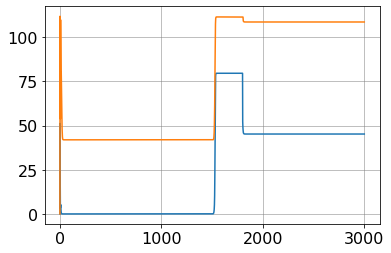

[[4.51992374e+01 1.08584101e+02]
 [4.47855997e-05 4.19187911e+01]]


In [116]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 3.

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] * 1.1
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1] * 1.1

low state vars =  [ 4.03070397e-005  3.77269120e+001 -3.15972236e-001  1.33113018e+000
  0.00000000e+000  7.96181395e-006  7.77573207e-001  7.44123811e-006
  8.34688519e-001  4.91461570e-007  1.16636320e-003  4.29295305e-007
  7.80390585e-004  2.18058628e-264  1.63543971e-264  1.35556200e+000
  1.35050210e+000 -6.48238727e+001  1.93187003e+001  1.17597868e+000]


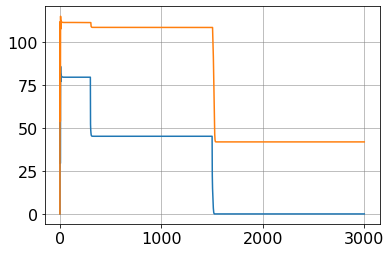

In [118]:
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.9
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1] * 0.9

print("low state vars = ", low_state_vars)

### A

In [119]:
dur = 20
dur_pre = 5
dur_post = 5
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

control0 = aln.getZeroControl()

# set high state rates as target
target_lh = aln.getZeroTarget()
target_lh[:,0,:] = 2. * steady_rates[0,0]
target_lh[:,1,:] = 2. * steady_rates[0,1]

tol = 1e-12
start_step = 100.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [ ]:
# A.1) low => high, current control, max current 1nA, precision only
case = "A1"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 1e3 * 1. * 5.
min_cntrl = - max_cntrl
cntrl_vars = [0,1]
prec_vars = [0,1]

aln.params.duration = dur

max_it = 200

setinit(low_state_vars)
control0 = aln.getZeroControl()
control1 = bestControlA1[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlA1, bestStateA1, costA1, runtimeA1, gradA1 = aln.A1(control0, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultA1 = {"Opt_control": bestControlA1,
              "Opt_state": bestStateA1,
              "costArray": costA1,
              "runtimeArray": runtimeA1,    
}

dump_dicts = [opt_params, aln.params, resultA1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

# RUN  0 , total integrated cost =  65195.87990054026
# RUN  100 , total integrated cost =  4314.07986318187

set cost params


0.27891437185556467 -2.7099175928793846


'\n50   0.2350917894862463 -4.3618525012907785\n100  0.23509595165172842 -3.3207596626305045\n'

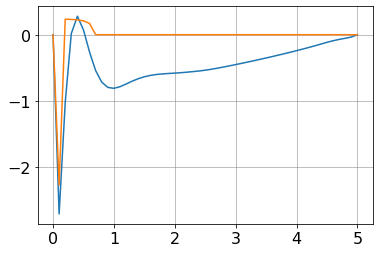

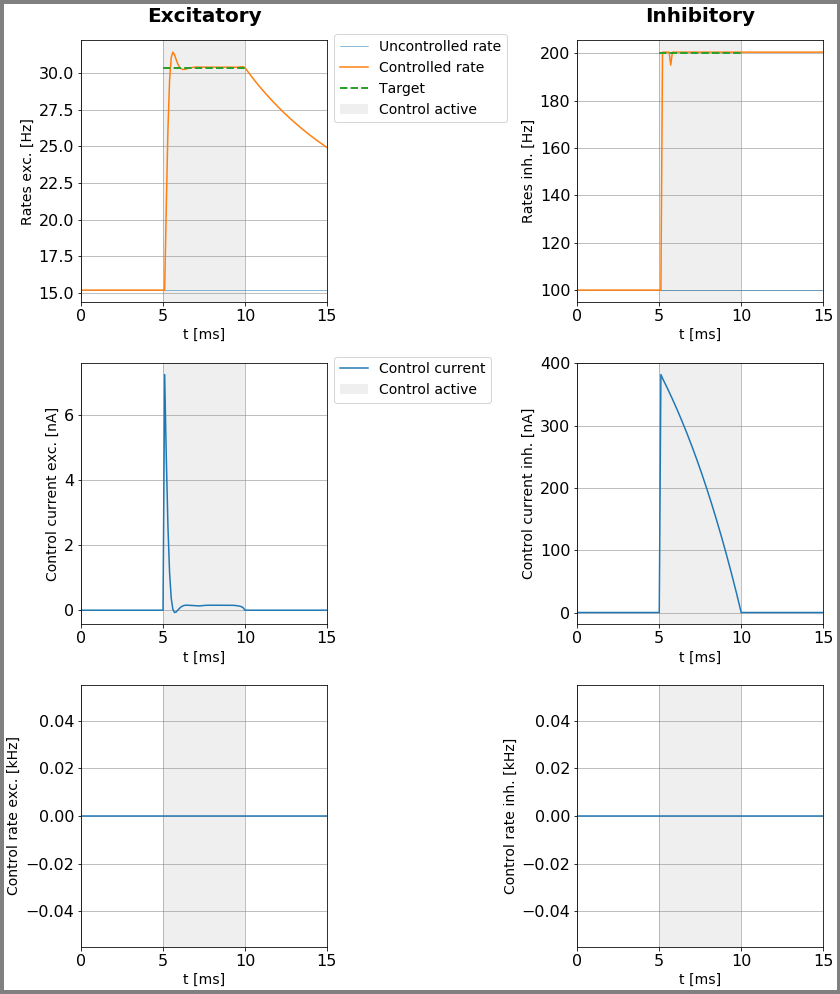

In [111]:
print(np.amax(gradA1), np.amin(gradA1))
t = np.arange(0,dur+aln.params.dt,aln.params.dt)
plt.plot(t, gradA1[0,0,:])
plt.plot(t, gradA1[0,1,:])

plotFunc.plot_control(aln, bestControlA1, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = case )

"""
50   0.2350917894862463 -4.3618525012907785
100  0.23509595165172842 -3.3207596626305045
"""

In [112]:
# A.2) low => high, max current 1nA, precision + energy + sparsity
case = "A2"
cost.setParams(1.0, 10.0, 10.0)
max_cntrl = 1. * 5.
aln.params.duration = dur
cntrl_vars = [0,1]
prec_vars = [0,1]

max_it = 200

setinit(low_state_vars)
control0 = aln.getZeroControl()
control1 = bestControlA1[:,:,n_pre-1:-n_pre+1]
control2 = bestControlA2[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlA2, bestStateA2, costA2, runtimeA2, gradA2 = aln.A1(control1, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = 1e3 * max_cntrl, min_control_ = 1e3 * min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars)

resultA2 = {"Opt_control": bestControlA2,
              "Opt_state": bestStateA2,
              "costArray": costA2,
              "runtimeArray": runtimeA2,    
}

dump_dicts = [opt_params, aln.params, resultA2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )
#RUN  7 , total integrated cost =  14667.918262655367

set cost params
RUN  0 , total integrated cost =  36421338.52874554
RUN  1 , total integrated cost =  35256.93784230675
RUN  2 , total integrated cost =  23169.371070603105
RUN  3 , total integrated cost =  22819.79505892236
RUN  4 , total integrated cost =  7396.7054285134245
RUN  5 , total integrated cost =  4649.7872264267035
RUN  6 , total integrated cost =  4618.479932910637
RUN  7 , total integrated cost =  3392.877066688756
RUN  8 , total integrated cost =  3220.0314254393593
RUN  9 , total integrated cost =  3174.3396249262087
RUN  10 , total integrated cost =  3173.009267772308
RUN  11 , total integrated cost =  3169.7486277093067
RUN  12 , total integrated cost =  3169.738241945623
RUN  13 , total integrated cost =  3168.4569106998747
RUN  14 , total integrated cost =  3168.4566755455285
RUN  15 , total integrated cost =  3168.4566693411407
RUN  16 , total integrated cost =  3168.456667871775
RUN  17 , total integrated cost =  3168.456667408289
RUN  18 , total integrated cost

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  3168.4566671710168
Control only changes marginally.
RUN  31 , total integrated cost =  3168.4566671710168
Improved over  31  iterations by  99.99130054853785  percent.
Problem in initial value trasfer:  tau_exc 1.7645374264606406 12.063080910762256
Problem in initial value trasfer:  tau_inh 0.42099999999999993 6.6946527507889515
Problem in initial value trasfer:  Vmean_exc -54.986798507890676 -54.98583550915479
Problem in initial value trasfer:  tau_exc 0.9966791354629319 10.299158410713657
Problem in initial value trasfer:  tau_inh 0.16099999999999998 -913046769809.3406


31.177410005315213 -10.932580229752617


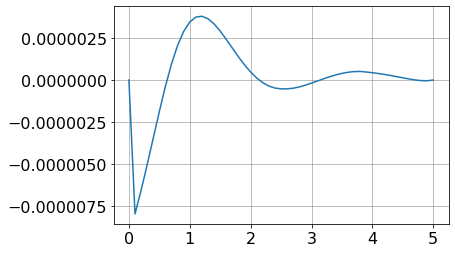

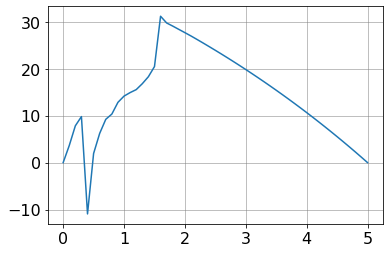

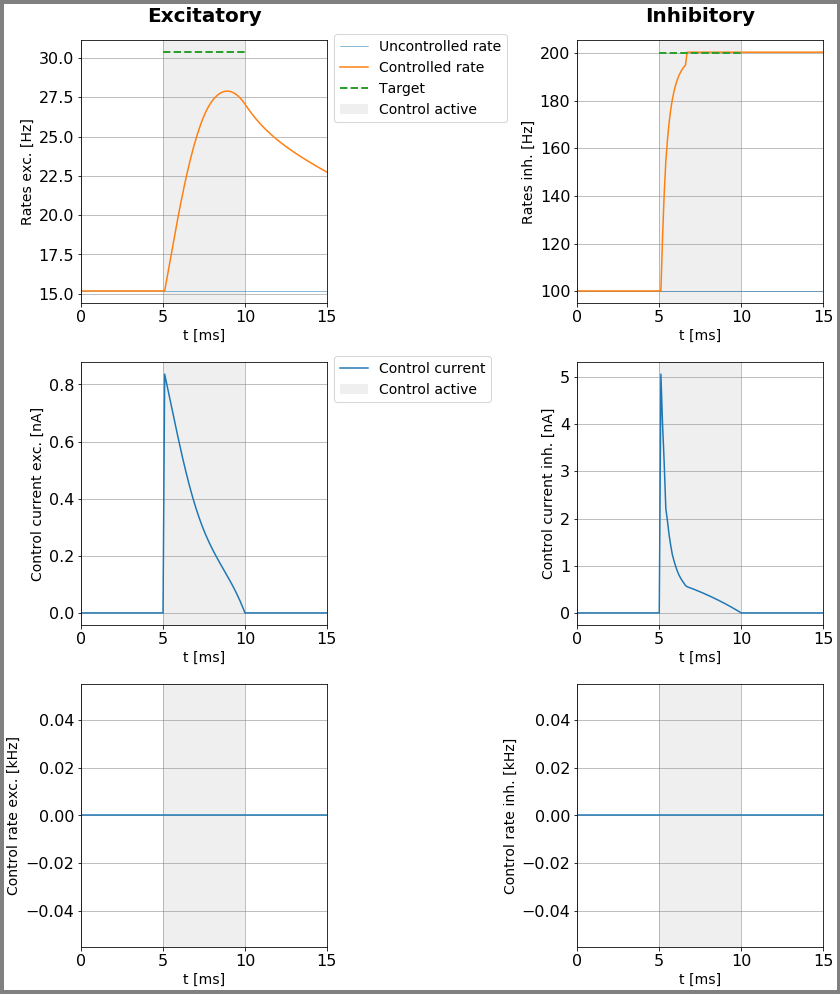

In [114]:
print(np.amax(gradA2), np.amin(gradA2))
t = np.arange(0,dur+aln.params.dt,aln.params.dt)
plt.plot(t, gradA2[0,0,:])
plt.show()
plt.plot(t, gradA2[0,1,:])
plt.show()

plotFunc.plot_control(aln, bestControlA2, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = case )

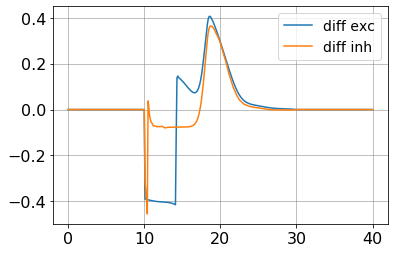

In [10]:
diff = 0.2*(bestControlA2 - bestControlA1)

t = np.arange(0, (dur+dur_pre+dur_post+0.1), 0.1)
plt.plot(t, diff[0,0,:], label = "diff exc")
plt.plot(t, diff[0,1,:], label = "diff inh")
plt.legend()
plt.show()

In [14]:
# A.3) low => high, rate control, max rate 100Hz, precision only
case = "A3"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 0.1
cntrl_vars = [2]
aln.params.duration = dur

max_it = 5000

setinit(low_state_vars)
control0 = aln.getZeroControl()


# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlA3, bestStateA3, costA3, runtimeA3, gradA3 = aln.A1(control0, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars)

resultA3 = {"Opt_control": bestControlA3,
              "Opt_state": bestStateA3,
              "costArray": costA3,
              "runtimeArray": runtimeA3,    
}

dump_dicts = [opt_params, aln.params, resultA3]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  65195.87990054026
RUN  1 , total integrated cost =  39311.70594237719
RUN  2 , total integrated cost =  39254.96962439755
RUN  3 , total integrated cost =  39242.254302731846
RUN  4 , total integrated cost =  39237.944536518895
RUN  5 , total integrated cost =  39235.045637165014
RUN  6 , total integrated cost =  39234.13899423343
RUN  7 , total integrated cost =  39233.30089755711
RUN  8 , total integrated cost =  39232.835716694826
RUN  9 , total integrated cost =  39232.421632277175
RUN  10 , total integrated cost =  39232.162904681725
RUN  11 , total integrated cost =  39231.93395847
RUN  12 , total integrated cost =  39231.771586669754
RUN  13 , total integrated cost =  39231.62686848262
RUN  14 , total integrated cost =  39231.52239434578
RUN  15 , total integrated cost =  39231.429454870646
RUN  16 , total integrated cost =  39231.35963850149
RUN  17 , total integrated cost =  39231.29760109645
RUN  18 , total integrated cost =  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  2978 , total integrated cost =  39230.85459651786
Improved over  2978  iterations by  39.82617512584141  percent.
Problem in initial value trasfer:  sigmae_f 1.5061818006347805 1.5061737188286086
Problem in initial value trasfer:  tau_exc 21.399339496785732 21.399385578873147
Problem in initial value trasfer:  Vmean_exc -56.695975267310494 -56.69624188543999


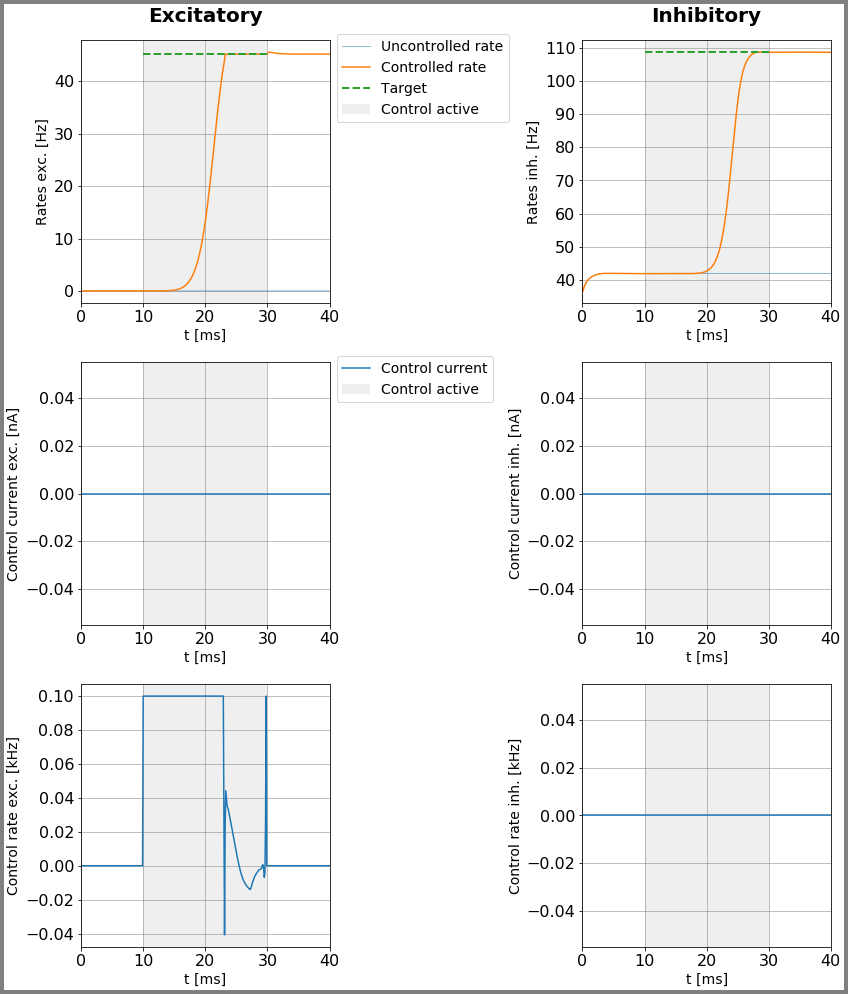

In [15]:
plotFunc.plot_control(aln, bestControlA3, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = case )

In [13]:
print(gradA3[:,:,-10:])

[[[ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
    0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
  [ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
    0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
  [-1.2956e-01 -1.2030e-01 -4.3945e-02  9.8129e-02  2.6006e-01
    3.5142e-01  2.7357e-01 -1.2107e-05 -5.8378e-05  0.0000e+00]
  [ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
    0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]]]
